# Aprendizaje No Supervisado

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession

print("🚀 CARGANDO TABLA GOLD DESDE HDFS...")

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("GeoLumica-ML-Clustering") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

HDFS_GOLD = "hdfs://localhost:9000/geolumica/gold"
df_gold = spark.read.parquet(HDFS_GOLD).toPandas()

print(f"✅ Gold cargado: {df_gold.shape[0]} filas x {df_gold.shape[1]} columnas")
print(f"   Años disponibles: {sorted(df_gold['year'].unique())}")


🔌 Conexión establecida con GeoLúmica DB: proyecto_big_data
8131 municipios cargados en memoria.
 Dimensiones listas: Luz, Demografía, PIB, Migración, Conectividad, Consumo, OSM y Empresas.


In [ ]:
print("🔍 COLUMNAS DISPONIBLES EN GOLD:")
print(list(df_gold.columns))


🔍 INSPECCIÓN DE COLUMNAS EN MEMORIA:
Demografía: ['region_code', 'region_name', 'year', 'provincia_population', 'municipio', 'Total', 'Hombres', 'Mujeres', 'muni_id_join']
VIIRS (Luces): ['AREA_KM2', 'CNTR_CODE', 'GISCO_ID', 'LAU_ID', 'LAU_NAME', 'date', 'max', 'mean', 'min', 'stdDev', 'PROV_NAME', 'mean_prov', 'muni_id_join']
PIB/Renta: ['provincia', 'nombre_municipio', 'muni_id_join', 'anio', 'pib']
OSM (Trenes): ['PROV_NAME', 'SOG_ID', 'LAU_ID', 'LAU_NAME', 'AREA_KM2', 'POP_2023', 'stations_count', 'stations_unique', 'stations_density_km2', 'stations_with_operator_share', 'operator_count', 'stations_per_10k_pop', 'stations_within_1km_count', 'stations_within_5km_count', 'stations_in_muni_plus_1km_count', 'stations_in_muni_plus_5km_count', 'min_distance_km_to_station', 'mean_distance_km_to_station', 'accessible_count', 'accessible_share', 'category_connectivity', 'INE_PROV_CODE', 'muni_id_join']
Empresas: ['codigo', 'nombre', 'tipo', '2012', '2013', '2014', '2015', '2016', '2017', '2

In [ ]:
print("\n" + "="*75)
print("📊 VERIFICACIÓN DE COBERTURA MULTI-DIMENSIONAL (DESDE GOLD)")
print("="*75)

total_munis = df_gold['muni_id_join'].nunique()
print(f"Total municipios en Gold: {total_munis}")
print(f"Total filas (municipio x año): {len(df_gold)}\n")

cols_check = {
    "Demografía":   "pob_absoluta_actual",
    "VIIRS":        "luz_absoluta_actual",
    "Renta/PIB":    "pib_absoluto_actual",
    "Migración":    "saldo_migratorio_neto",
    "Conectividad": "Indice_Conectividad",
    "OSM Trenes":   "mean_distance_km_to_station",
    "Empresas":     "empresas_transporte_actual",
    "Energía":      "consumo_kwh_total",
}

for nombre, col in cols_check.items():
    if col in df_gold.columns:
        cobertura = df_gold[col].notna().mean() * 100
        print(f"▶ {nombre:<20} | {cobertura:>6.2f}% valores no nulos  [{col}]")
    else:
        print(f"▶ {nombre:<20} | ❌ columna '{col}' no existe en Gold")
print("="*75)



📊 VERIFICACIÓN DE COBERTURA MULTI-DIMENSIONAL (DESDE MySQL)
Total de municipios en el maestro (dim_geografia): 8131

▶ Demografía         |  8113 municipios vinculados |  99.78% cobertura
  ⚠️ Faltan 18 municipios.
  🔍 Ejemplos perdidos: Cabanes, Mieres, Fonfría...
---------------------------------------------------------------------------
▶ Luces (VIIRS)      |  8131 municipios vinculados | 100.00% cobertura
  ✅ ¡PERFECTO! 100% de cobertura.
---------------------------------------------------------------------------
▶ Renta/PIB          |  8123 municipios vinculados |  99.90% cobertura
  ⚠️ Faltan 8 municipios.
  🔍 Ejemplos perdidos: Benitagla, Carrascalejo, El, Tresviso...
---------------------------------------------------------------------------
▶ Migraciones        |  8131 municipios vinculados | 100.00% cobertura
  ✅ ¡PERFECTO! 100% de cobertura.
---------------------------------------------------------------------------
▶ Conectividad       |  8131 municipios vinculados | 100.0

## **Feature Engineering y PCA**

A partir de los datos del INE, calculamos:
* **`pob_absoluta_actual`**: Población total en el último año censado (escala del municipio).
* **`delta_pob_pct`**: Tasa de variación porcentual histórica. Valores negativos fuertes indican despoblación profunda.
* **`ratio_masculinidad`**: `(Hombres / Mujeres)`. En sociología rural, un valor inusualmente alto señala un núcleo en declive por la emigración de mujeres jóvenes.

In [ ]:
print("⚙️ [1/5] Construyendo Matriz Maestra desde Gold (snapshot último año)...")

max_yr = df_gold['year'].max()
min_yr = df_gold['year'].min()
df_last = df_gold[df_gold['year'] == max_yr].copy()

# Históricos para calcular deltas (Gold ya usa los nombres finales)
df_first = df_gold[df_gold['year'] == min_yr][['muni_id_join', 'pob_absoluta_actual', 'luz_absoluta_actual']].rename(
    columns={'pob_absoluta_actual': 'pob_historica', 'luz_absoluta_actual': 'luz_historica'}
)

# Snapshot último año — Gold ya exporta los nombres de df_master directamente
df_master = df_last[[
    'muni_id_join', 'muni_display', 'prov_id_join',
    'pob_absoluta_actual', 'luz_absoluta_actual', 'luz_volatilidad_std',
    'mean_distance_km_to_station', 'stations_density_km2', 'Indice_Conectividad',
    'empresas_transporte_actual', 'num_vehiculos',
    'ratio_masculinidad', 'tasa_migratoria_pct',
    'pib_absoluto_actual',
]].copy()

# Deltas históricos
df_master = pd.merge(df_master, df_first, on='muni_id_join', how='left')
df_master['delta_pob_pct'] = ((df_master['pob_absoluta_actual'] - df_master['pob_historica']) / (df_master['pob_historica'] + 1)) * 100
df_master['delta_luz_pct'] = ((df_master['luz_absoluta_actual'] - df_master['luz_historica']) / (df_master['luz_historica'] + 0.01)) * 100
df_master = df_master.drop(columns=['pob_historica', 'luz_historica'])

print(f"✅ Esqueleto listo. Shape: {df_master.shape}")


⚙️ [1/5] Creando Esqueleto y calculando Deltas Demográficos...


* **`luz_absoluta_actual`**: Radiancia media del último año. Define el tamaño físico/lumínico de la zona.
* **`delta_luz_pct`**: Crecimiento de la luz a lo largo de los años. Si es alto pero la población no crece, indica expansión industrial/logística.
* **`luz_volatilidad_std`**: Desviación estándar mensual. Suavizamos los picos para detectar **estacionalidad** (zonas turísticas que brillan en verano y se apagan en invierno).

In [ ]:
print("⚙️ [2/5] Calculando Pct_Vehiculos_Muni_vs_Prov y delta_empresas_transporte_pct...")

# Pct_Vehiculos_Muni_vs_Prov: vehículos del municipio como % del total provincial
prov_vehiculos = df_master.groupby('prov_id_join')['num_vehiculos'].transform('sum')
df_master['Pct_Vehiculos_Muni_vs_Prov'] = (df_master['num_vehiculos'] / (prov_vehiculos + 1)) * 100
df_master = df_master.drop(columns=['num_vehiculos'])

# delta_empresas_transporte_pct: crecimiento de empresas entre primer y último año
df_first_emp = df_gold[df_gold['year'] == min_yr][['muni_id_join', 'empresas_transporte_actual']].rename(
    columns={'empresas_transporte_actual': 'empresas_historicas'}
)
df_master = pd.merge(df_master, df_first_emp, on='muni_id_join', how='left')
df_master['delta_empresas_transporte_pct'] = (
    (df_master['empresas_transporte_actual'] - df_master['empresas_historicas']) /
    (df_master['empresas_historicas'] + 1)
) * 100
df_master = df_master.drop(columns=['empresas_historicas'])

print(f"✅ Variables de movilidad calculadas. Shape: {df_master.shape}")


⚙️ [2/5] Procesando Satélites VIIRS (Consumo y Volatilidad)...
  ✅ VIIRS procesado e integrado con éxito.


Integramos los datos de la Agencia Tributaria sobre la renta disponible local.
* **`pib_absoluto_actual`**: Renta total del último año.
* **`pib_media_historica`**: Promedio de riqueza a lo largo del histórico.
* **`pib_volatilidad_std`**: Nivel de fluctuación de la economía (resiliencia frente a crisis).
* **Imputación**: A los municipios protegidos por el *Secreto Estadístico*, se les imputa automáticamente la media económica de su provincia.

In [ ]:
print("⚙️ [3/5] Integrando Riqueza e Imputando Secreto Estadístico...")

# pib_absoluto_actual ya viene desde Gold con ese nombre
# pib_media_historica y pib_volatilidad_std calculadas desde el histórico completo de Gold
pib_stats = df_gold.groupby('muni_id_join')['pib_absoluto_actual'].agg(
    pib_media_historica='mean',
    pib_volatilidad_std='std'
).reset_index()

df_master = pd.merge(df_master, pib_stats, on='muni_id_join', how='left')

# Imputación: municipios sin dato (secreto estadístico) → mediana de su provincia
for col in ['pib_absoluto_actual', 'pib_media_historica', 'pib_volatilidad_std']:
    df_master[col] = df_master.groupby('prov_id_join')[col].transform(lambda x: x.fillna(x.median()))

print(f"✅ Riqueza integrada. Shape: {df_master.shape}")


⚙️ [3/5] Integrando Riqueza e Imputando Secreto Estadístico...


Combinamos variables de distintas fuentes para capturar el atractivo y la conectividad del territorio. Para normalizar los datos y evitar que el tamaño del municipio domine el modelo, usamos tasas y variaciones:

* **`delta_empresas_transporte_pct`**: Crecimiento del tejido logístico. *Cálculo: `((Empresas_Actuales - Empresas_Historicas) / Empresas_Historicas) * 100`*. Picos masivos (+400%) en zonas no metropolitanas detectan nuevos grandes nodos logísticos periféricos (el "Efecto Amazon").
* **`stations_density_km2`**: Nivel de infraestructura ferroviaria metropolitana por kilómetro cuadrado. Diferencia los núcleos urbanos densos del resto.
* **`Indice_Conectividad`**: Nivel de motorización general (vehículos).
* **`Pct_Vehiculos_Muni_vs_Prov`**: Porcentaje del parque automotor de la provincia que se concentra en este municipio específico. Detecta las "capitales de facto" en términos de movilidad.
* **`tasa_migratoria_pct`**: Tasa de presión migratoria. *Cálculo: `(Migrantes Totales / Población Total) * 100`*. Transforma el volumen bruto en una "presión de atracción" comparable, revelando si un pueblo pequeño atrae a mucha gente en proporción a su tamaño.

In [ ]:
print("⚙️ [4/5] ✅ Conectividad, OSM, migración y movilidad ya integrados desde Gold en pasos anteriores.")
print(f"\n   Shape actual: {df_master.shape}")
print(f"   Columnas disponibles:\n   {list(df_master.columns)}")


⚙️ [4/5] Fusionando Empresas, Transporte (OSM) y Magnetismo Migratorio...


Tratamiento matemático final de la matriz antes de inyectarla en los algoritmos:
* **Penalización de Aislamiento**: A los municipios sin datos de distancia ferroviaria en OSM se les imputa un valor extremo (`100.0` km) para que el modelo los segregue correctamente como "Aislados".
* El resto de valores residuales nulos (pueblos minúsculos sin datos de empresas) se rellenan con `0`.

In [ ]:
print("⚙️ [5/5] Limpieza de Nulos Residuales (Penalizaciones Matemáticas)...")

# Penalizamos los pueblos aislados sin estación de tren con 100 km
df_master['mean_distance_km_to_station'] = df_master['mean_distance_km_to_station'].fillna(100.0)

# El resto de variables no mapeadas (pueblos sin registros) a cero
df_master = df_master.fillna(0)

print("\n" + "="*80)
print(f"✅ ¡MATRIZ MAESTRA LISTA PARA PCA! Dimensiones: {df_master.shape[0]} filas x {df_master.shape[1]} columnas.")
print("="*80)
display(df_master.head())


⚙️ [5/5] Limpieza de Nulos Residuales (Penalizaciones Matemáticas)...

✅ ¡MATRIZ MAESTRA LISTA PARA PCA! Dimensiones: 8133 filas x 19 columnas.


,muni_id_join,muni_display,prov_id_join,pob_absoluta_actual,delta_pob_pct,ratio_masculinidad,luz_absoluta_actual,delta_luz_pct,luz_volatilidad_std,pib_absoluto_actual,pib_media_historica,pib_volatilidad_std,empresas_transporte_actual,delta_empresas_transporte_pct,Indice_Conectividad,Pct_Vehiculos_Muni_vs_Prov,stations_density_km2,mean_distance_km_to_station,tasa_migratoria_pct
0,01001,Alegría-Dulantzi,01,2955.0,139.352227,1.062033,3.26575,98.812791,1.167833,16429.0,14124.888889,1140.551779,47.0,-14.285714,15.23,0.8824,0.013,16.692,5.784844
1,01002,Amurrio,01,10364.0,6.209653,0.981247,1.94885,101.906294,0.658661,17486.0,14857.777778,1246.115141,209.0,-18.604651,73.55,3.0625,0.262,13.071,2.595273
2,01003,Aramaio,01,1354.0,0.668648,1.029831,0.92065,120.220066,0.318583,20577.0,17935.111111,1696.047055,20.0,-12.500000,55.78,0.4188,0.933,14.020,2.214022
3,01004,Artziniega,01,1868.0,44.435858,0.976616,1.43270,24.282597,0.713846,16408.0,13849.222222,1326.410361,29.0,-40.000000,20.84,0.5442,0.313,13.046,3.959337
4,01006,Armiñón,01,236.0,69.285714,1.106155,3.66410,45.903122,1.405683,17000.0,14627.444444,1897.675757,0.0,0.000000,9.85,0.0689,0.111,11.244,7.172996


🧠 INICIANDO PIPELINE DE MACHINE LEARNING (Modelo Híbrido de Dos Fases)...
   -> Separando las Grandes Urbes del mundo Rural...
   🏙️ Gigantes aislados: 153 municipios.
   🌾 Municipios rurales a analizar: 7978 municipios.

✅ Datos rurales estandarizados. Forma de la matriz: (7978, 16)


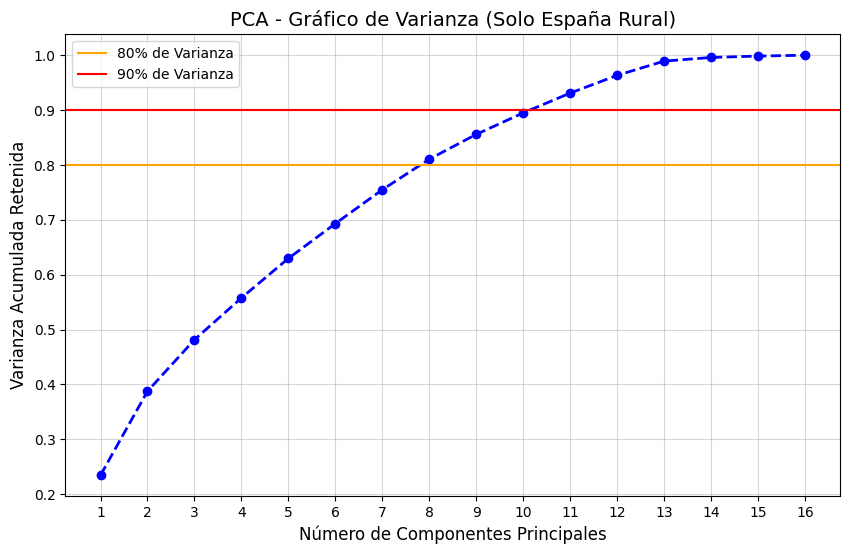


📊 Detalle de Varianza Acumulada por Componente:
Componente 1: 23.45% de la información original
Componente 2: 38.75% de la información original
Componente 3: 48.14% de la información original
Componente 4: 55.76% de la información original
Componente 5: 62.97% de la información original
Componente 6: 69.31% de la información original
Componente 7: 75.49% de la información original
Componente 8: 81.05% de la información original
Componente 9: 85.57% de la información original
Componente 10: 89.49% de la información original
Componente 11: 93.10% de la información original
Componente 12: 96.33% de la información original
Componente 13: 98.93% de la información original
Componente 14: 99.59% de la información original
Componente 15: 99.85% de la información original
Componente 16: 100.00% de la información original


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("🧠 INICIANDO PIPELINE DE MACHINE LEARNING (Modelo Híbrido de Dos Fases)...")

# 1. Limpieza de seguridad y borrado de columnas residuales
df_master = df_master.drop_duplicates(subset=['muni_id_join']).reset_index(drop=True)
columnas_basura = ['Cluster_GeoLumina', 'Perfil_Territorial', 'Cluster_KMeans']
df_master = df_master.drop(columns=columnas_basura, errors='ignore')

# ---------------------------------------------------------
# 🚨 FASE 1: EL FILTRO METROPOLITANO (Separamos a los Gigantes)
# ---------------------------------------------------------
print("   -> Separando las Grandes Urbes del mundo Rural...")
# Filtramos ciudades de más de 50.000 habitantes (aprox. 150 municipios en España)
mascara_gigantes = df_master['pob_absoluta_actual'] > 50000

df_gigantes = df_master[mascara_gigantes].copy()
df_rural = df_master[~mascara_gigantes].copy()

print(f"   🏙️ Gigantes aislados: {len(df_gigantes)} municipios.")
print(f"   🌾 Municipios rurales a analizar: {len(df_rural)} municipios.")

# 2. Separar el "Alma" del "Cuerpo" SOLO para el mundo rural
df_ids_rural = df_rural[['muni_id_join', 'muni_display', 'prov_id_join']].reset_index(drop=True)
df_features_rural = df_rural.drop(columns=['muni_id_join', 'muni_display', 'prov_id_join']).reset_index(drop=True)

# 3. Estandarización (Escalado Z-Score clásico) SOLO al mundo rural
scaler = StandardScaler()
features_scaled_rural = scaler.fit_transform(df_features_rural)

print(f"\n✅ Datos rurales estandarizados. Forma de la matriz: {features_scaled_rural.shape}")

# 4. Calcular PCA (Para todas las componentes posibles)
pca = PCA()
pca.fit(features_scaled_rural)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# 5. Crear el Gráfico del "Codo" (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b', linewidth=2)
plt.axhline(y=0.80, color='orange', linestyle='-', label='80% de Varianza')
plt.axhline(y=0.90, color='red', linestyle='-', label='90% de Varianza')

plt.title('PCA - Gráfico de Varianza (Solo España Rural)', fontsize=14)
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Acumulada Retenida', fontsize=12)
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print("\n📊 Detalle de Varianza Acumulada por Componente:")
for i, var in enumerate(varianza_acumulada):
    print(f"Componente {i+1}: {var*100:.2f}% de la información original")

#### Extracción de Componentes y Mapa de Calor (Loadings)

Tras analizar la varianza explicada, determinamos que con **10 Componentes Principales** retenemos casi el **89%** de la información original, reduciendo el ruido pero manteniendo la esencia matemática de las 16 variables originales.

A continuación, extraemos los **Pesos (Loadings)**. Los Loadings nos indican cuánto contribuye cada variable original a cada nuevo Componente Principal. 
* Un valor cercano a `1` (rojo oscuro) o `-1` (azul oscuro) indica una correlación fortísima.
* Un valor cercano a `0` (blanco) indica que esa variable no tiene peso en ese componente.

In [10]:
import seaborn as sns

print("⚙️ [1/2] Aplicando PCA Definitivo a la España Rural (10 Componentes)...")

# 1. Ajustamos el PCA final a 10 componentes
pca_final = PCA(n_components=10, random_state=42)
matriz_pca_rural = pca_final.fit_transform(features_scaled_rural)

print(f"✅ Matriz reducida lista. Nueva forma: {matriz_pca_rural.shape}")

# 2. Generamos el dataset para el K-Means
nombres_pc = [f'PC{i+1}' for i in range(10)]
df_pca_rural = pd.DataFrame(matriz_pca_rural, columns=nombres_pc)
df_clustering_rural = pd.concat([df_ids_rural, df_pca_rural], axis=1)

print("🚀 LISTOS PARA K-MEANS: Dataset 'df_clustering_rural' generado con éxito.")

⚙️ [1/2] Aplicando PCA Definitivo a la España Rural (10 Componentes)...
✅ Matriz reducida lista. Nueva forma: (7978, 10)
🚀 LISTOS PARA K-MEANS: Dataset 'df_clustering_rural' generado con éxito.


⚙️ Evaluando el K óptimo SOLO para la España Rural...


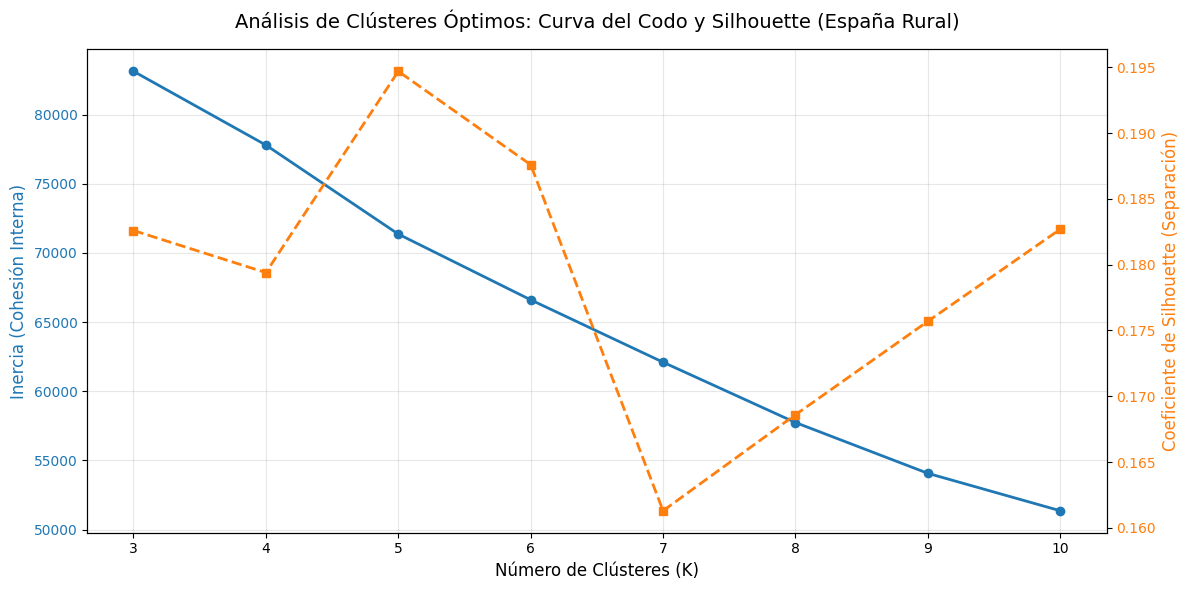


📊 TABLA DE MÉTRICAS MATEMÁTICAS POR 'K' (ESPAÑA RURAL):


,K,Inercia,Descenso_Inercia,Silhouette
0,3,83122.52,0.00,0.1826
1,4,77792.58,5329.94,0.1794
2,5,71358.31,6434.27,0.1947
3,6,66607.08,4751.23,0.1876
4,7,62098.81,4508.28,0.1613
5,8,57740.65,4358.15,0.1686
6,9,54069.26,3671.40,0.1757
7,10,51365.46,2703.80,0.1827


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

print("⚙️ Evaluando el K óptimo SOLO para la España Rural...")

# 1. Aislamos las 10 columnas numéricas del PCA RURAL (quitamos los textos)
# 🚨 CAMBIO CLAVE: Usamos df_clustering_rural
X_clustering_rural = df_clustering_rural.drop(columns=['muni_id_join', 'muni_display', 'prov_id_join'])

# 2. Variables para guardar métricas
resultados = []
rango_k = range(3, 11)

# 3. Bucle de entrenamiento
for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # 🚨 CAMBIO CLAVE: Entrenamos sobre X_clustering_rural
    etiquetas_temp = kmeans_temp.fit_predict(X_clustering_rural)
    
    inercia = kmeans_temp.inertia_
    silhouette = silhouette_score(X_clustering_rural, etiquetas_temp)
    
    resultados.append({
        'K': k,
        'Inercia': inercia,
        'Silhouette': silhouette
    })

# 4. Convertir a DataFrame y calcular el Descenso (Delta Inercia)
df_metricas = pd.DataFrame(resultados)
df_metricas['Descenso_Inercia'] = df_metricas['Inercia'].shift(1) - df_metricas['Inercia']
df_metricas['Descenso_Inercia'] = df_metricas['Descenso_Inercia'].fillna(0)
df_metricas = df_metricas[['K', 'Inercia', 'Descenso_Inercia', 'Silhouette']]

# Redondear para que la tabla se vea limpia
df_metricas['Inercia'] = df_metricas['Inercia'].round(2)
df_metricas['Descenso_Inercia'] = df_metricas['Descenso_Inercia'].round(2)
df_metricas['Silhouette'] = df_metricas['Silhouette'].round(4)

# 5. Creación del Panel Gráfico Dual
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Número de Clústeres (K)', fontsize=12)
ax1.set_ylabel('Inercia (Cohesión Interna)', color=color, fontsize=12)
ax1.plot(df_metricas['K'], df_metricas['Inercia'], marker='o', color=color, linewidth=2, label='Inercia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Coeficiente de Silhouette (Separación)', color=color, fontsize=12)
ax2.plot(df_metricas['K'], df_metricas['Silhouette'], marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Análisis de Clústeres Óptimos: Curva del Codo y Silhouette (España Rural)', fontsize=14, pad=15)
fig.tight_layout()
plt.show()

# 6. Mostrar la Tabla de Métricas Puras
print("\n📊 TABLA DE MÉTRICAS MATEMÁTICAS POR 'K' (ESPAÑA RURAL):")
display(df_metricas)

## Modelo No supervisado : K-means

In [38]:
from sklearn.cluster import KMeans

print("⚙️ [1/2] Entrenando K-Means SOLO en municipios rurales (K=6)...")

# 1. Entrenamos el K-Means con las variables del PCA
X_clustering_rural = df_clustering_rural.drop(columns=['muni_id_join', 'muni_display', 'prov_id_join'])
kmeans_rural = KMeans(n_clusters=6, random_state=42, n_init=20)
etiquetas_rurales = kmeans_rural.fit_predict(X_clustering_rural)

# Les ponemos un prefijo para saber que son los rurales
df_rural['Perfil_Territorial'] = ['Clúster Rural ' + str(c) for c in etiquetas_rurales]

# 2. Etiquetamos a los gigantes "a mano"
print("⚙️ [2/2] Reintegrando a las Grandes Urbes en el maestro...")
df_gigantes['Perfil_Territorial'] = '0 - Grandes Urbes y Motores Regionales'

# 3. Volvemos a unir a toda España en un solo DataFrame
df_master_final = pd.concat([df_gigantes, df_rural]).reset_index(drop=True)

# 4. Calculamos los perfiles medianos de las 7 zonas resultantes
columnas_perfil = [
    'pob_absoluta_actual', 'delta_pob_pct', 'delta_luz_pct', 
    'pib_media_historica', 'delta_empresas_transporte_pct', 
    'mean_distance_km_to_station', 'ratio_masculinidad'
]

perfiles_clusters = df_master_final.groupby('Perfil_Territorial')[columnas_perfil].median().round(2)
perfiles_clusters['Total_Municipios'] = df_master_final['Perfil_Territorial'].value_counts()

cols = ['Total_Municipios'] + columnas_perfil
perfiles_clusters = perfiles_clusters[cols]

print("\n" + "="*100)
print("📊 RADIOGRAFÍA HÍBRIDA DE LAS 7 ESPAÑAS (1 Urbe + 6 Rurales)")
print("="*100)
display(perfiles_clusters)

# Actualizamos tu df_master original para que el mapa lo encuentre
df_master = df_master_final.copy()

⚙️ [1/2] Entrenando K-Means SOLO en municipios rurales (K=6)...
⚙️ [2/2] Reintegrando a las Grandes Urbes en el maestro...

📊 RADIOGRAFÍA HÍBRIDA DE LAS 7 ESPAÑAS (1 Urbe + 6 Rurales)


,Total_Municipios,pob_absoluta_actual,delta_pob_pct,delta_luz_pct,pib_media_historica,delta_empresas_transporte_pct,mean_distance_km_to_station,ratio_masculinidad
Perfil_Territorial,,,,,,,,
0 - Grandes Urbes y Motores Regionales,153,92237.0,24.37,37.45,12658.22,-12.46,0.00,0.95
Clúster Rural 0,1036,4440.5,72.17,47.84,12824.72,-6.39,0.00,1.02
Clúster Rural 1,3601,706.0,-19.91,163.93,10509.44,0.00,0.00,1.06
Clúster Rural 2,110,19538.5,42.94,52.42,12814.94,-15.49,0.00,0.96
Clúster Rural 3,348,22218.5,25.68,54.94,10677.28,-12.90,0.00,0.98
Clúster Rural 4,34,1162.5,42.42,77.86,11876.94,3450.00,0.00,1.04
Clúster Rural 5,2849,117.0,-27.78,246.64,14629.00,0.00,11.53,1.26


Cargando geometrías desde GeoJSON...
Pintando perfiles territoriales...


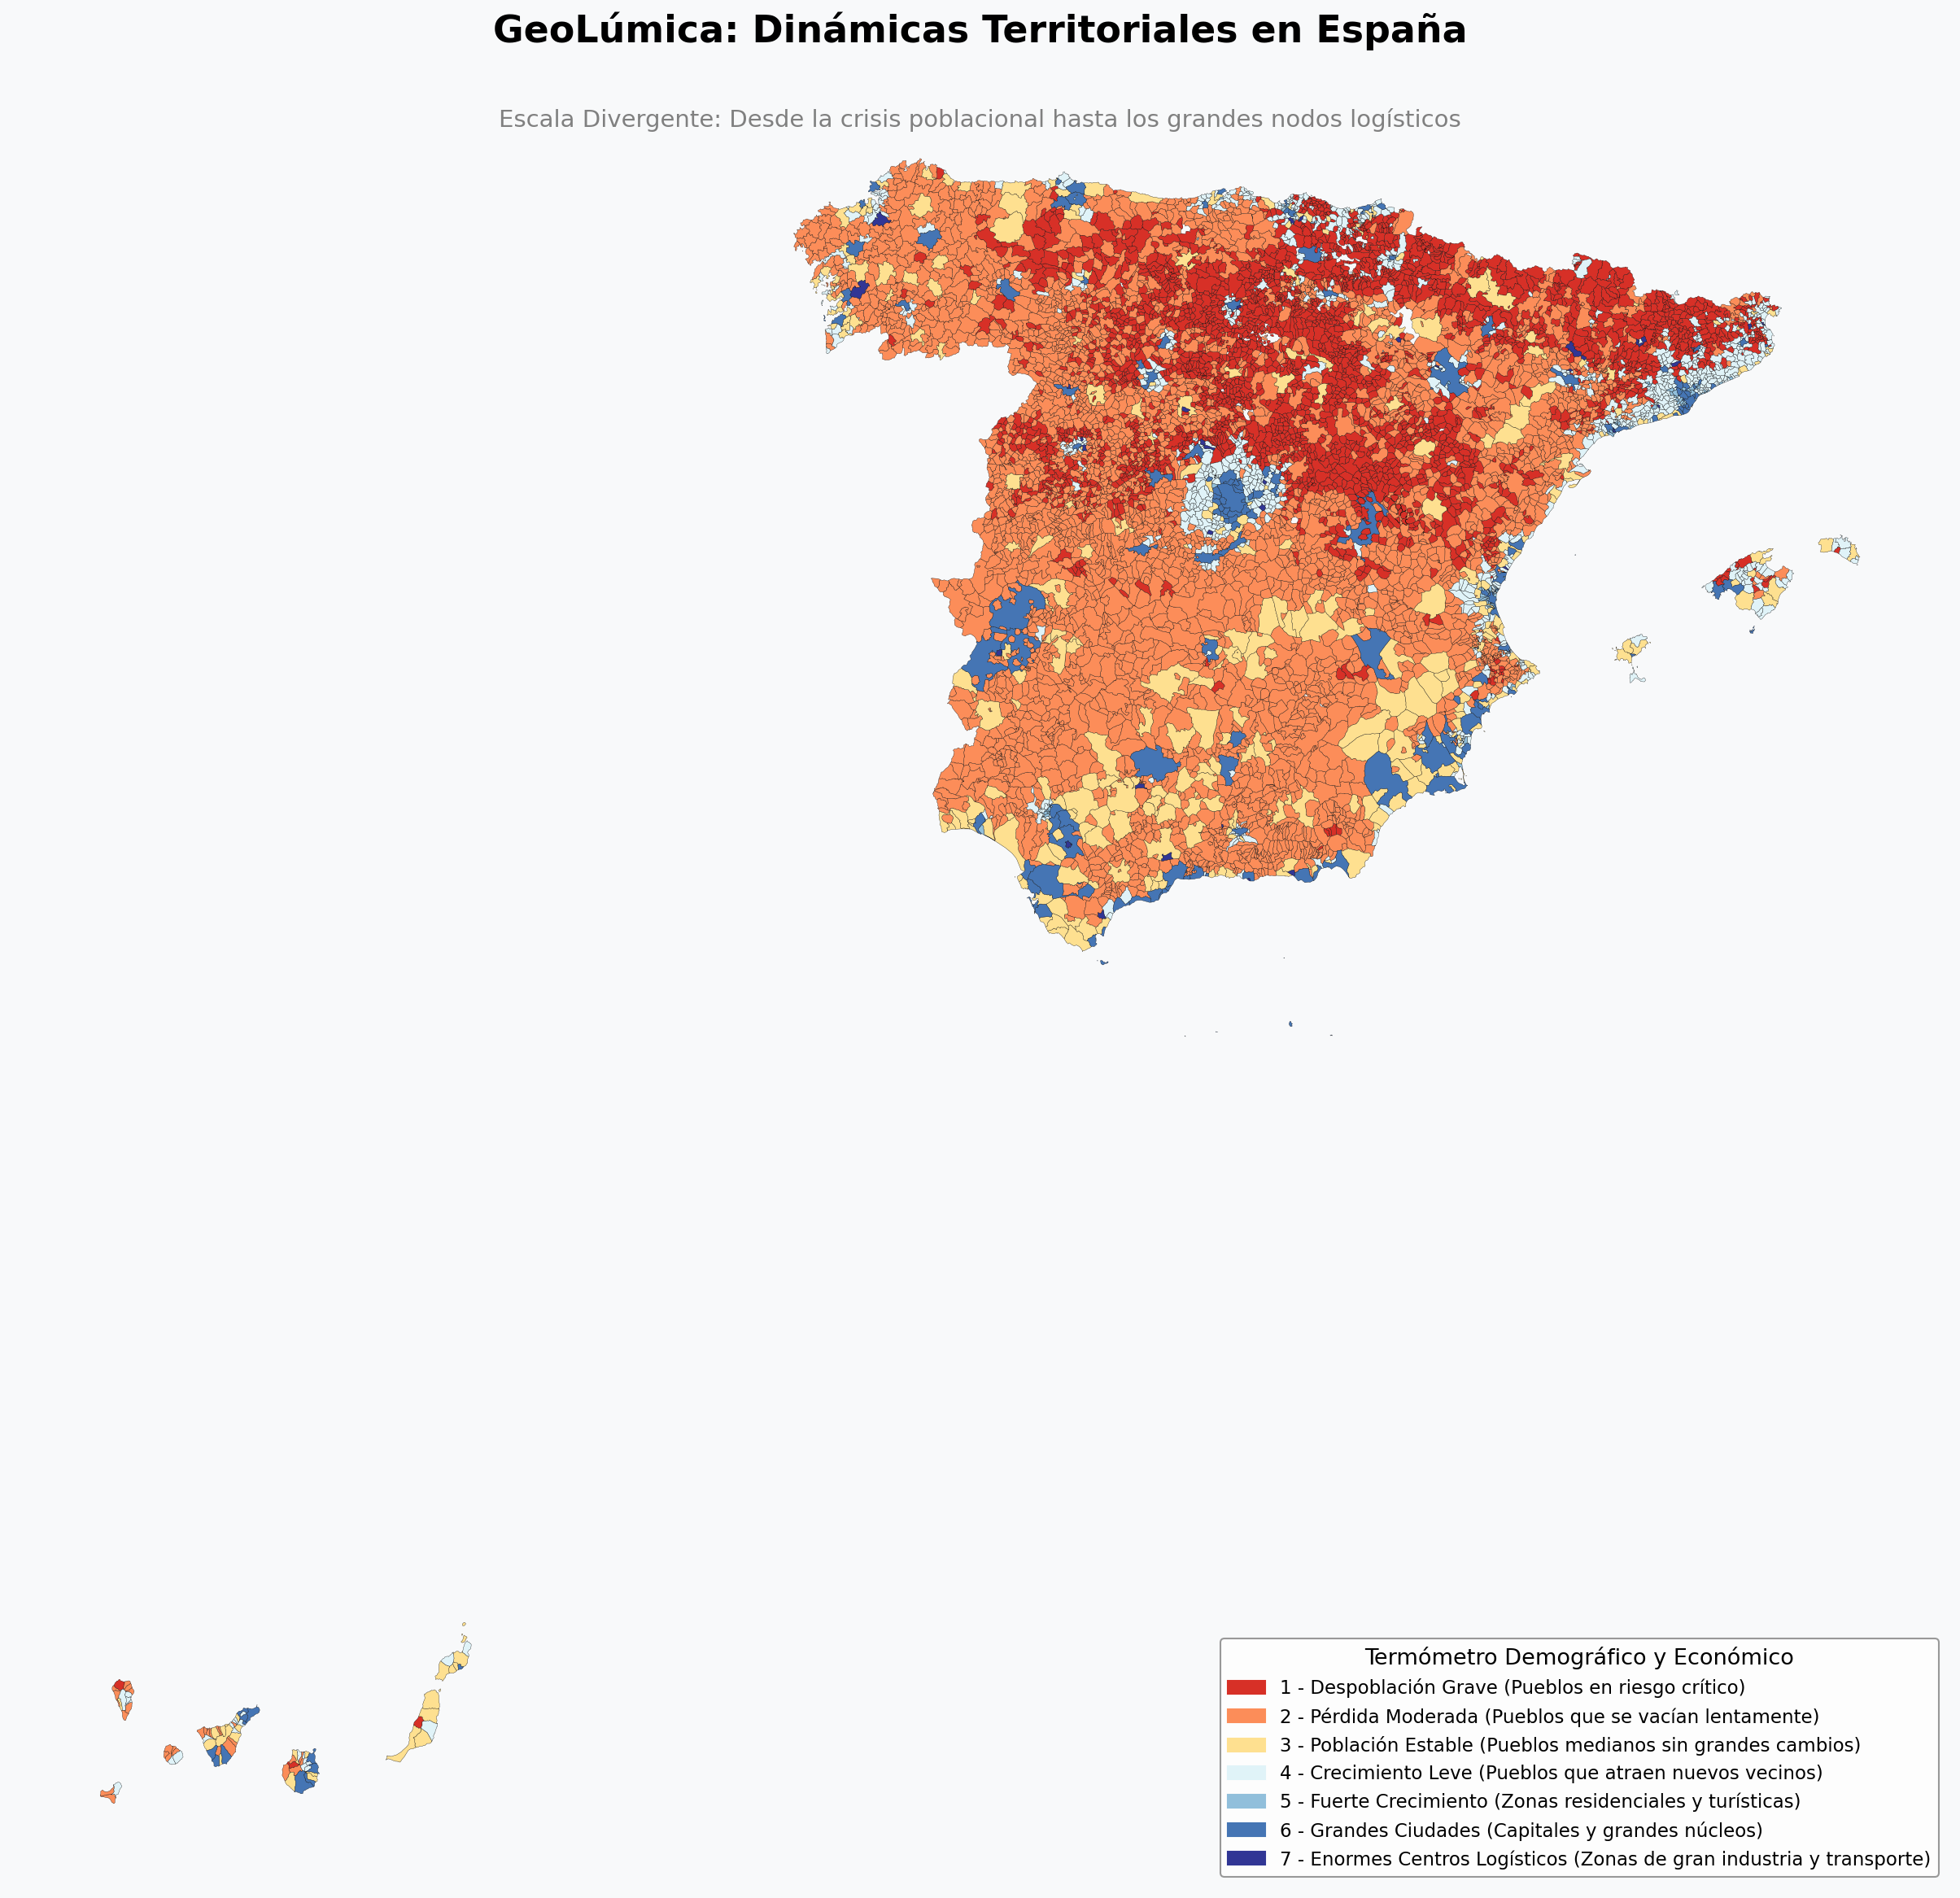

In [43]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import geopandas as gpd

# 1. Diccionario Definitivo: Nombres en lenguaje común, claros y directos
diccionario_divergente = {
    'Clúster Rural 5': '1 - Despoblación Grave (Pueblos en riesgo crítico)',
    'Clúster Rural 1': '2 - Pérdida Moderada (Pueblos que se vacían lentamente)',
    'Clúster Rural 3': '3 - Población Estable (Pueblos medianos sin grandes cambios)',
    'Clúster Rural 0': '4 - Crecimiento Leve (Pueblos que atraen nuevos vecinos)',
    'Clúster Rural 2': '5 - Fuerte Crecimiento (Zonas residenciales y turísticas)',
    '0 - Grandes Urbes y Motores Regionales': '6 - Grandes Ciudades (Capitales y grandes núcleos)',
    'Clúster Rural 4': '7 - Enormes Centros Logísticos (Zonas de gran industria y transporte)'
}

# Aplicamos los nombres a nuestra matriz
df_master['Perfil_Final'] = df_master['Perfil_Territorial'].map(diccionario_divergente)

# 2. Definimos la paleta divergente exacta (De Rojo a Azul)
colores_divergentes = {
    '1 - Despoblación Grave (Pueblos en riesgo crítico)': '#d73027',        # Rojo Alerta
    '2 - Pérdida Moderada (Pueblos que se vacían lentamente)': '#fc8d59',   # Naranja
    '3 - Población Estable (Pueblos medianos sin grandes cambios)': '#fee090', # Amarillo
    '4 - Crecimiento Leve (Pueblos que atraen nuevos vecinos)': '#e0f3f8',   # Azul muy clarito
    '5 - Fuerte Crecimiento (Zonas residenciales y turísticas)': '#91bfdb', # Azul claro
    '6 - Grandes Ciudades (Capitales y grandes núcleos)': '#4575b4',        # Azul oscuro
    '7 - Enormes Centros Logísticos (Zonas de gran industria y transporte)': '#313695' # Azul marino profundo
}

# 3. Cargamos geometrías
print("Cargando geometrías desde GeoJSON...")
ruta_geojson = '../municipios_es.geojson' # Ajusta tu ruta si hace falta
gdf_muni = gpd.read_file(ruta_geojson)
gdf_muni['LAU_ID'] = gdf_muni['LAU_ID'].astype(str).str.zfill(5)

# 4. Cruzamos el mapa espacial con nuestros datos finales
gdf_mapa = gdf_muni.merge(
    df_master[['muni_id_join', 'Perfil_Final']], 
    left_on='LAU_ID', 
    right_on='muni_id_join', 
    how='left'
)

# 5. Configuramos el lienzo del gráfico
fig, ax = plt.subplots(figsize=(18, 16), dpi=150)
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

print("Pintando perfiles territoriales...")

# Filtramos y pintamos nulos primero
nulos = gdf_mapa[gdf_mapa['Perfil_Final'].isna()]
if not nulos.empty:
    nulos.plot(ax=ax, color='#e0e0e0', linewidth=0.1)

# Pintamos capa por capa en el orden exacto del diccionario
leyenda_parches = []
for perfil, color_hex in colores_divergentes.items():
    subset = gdf_mapa[gdf_mapa['Perfil_Final'] == perfil]
    if not subset.empty:
        subset.plot(ax=ax, color=color_hex, linewidth=0.15, edgecolor='black')
        leyenda_parches.append(mpatches.Patch(color=color_hex, label=perfil))

# 6. Estética y Leyenda
ax.legend(
    handles=leyenda_parches, 
    title='Termómetro Demográfico y Económico', 
    loc='lower right', 
    fontsize=11, 
    title_fontsize=13,
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

ax.set_axis_off()
plt.title('GeoLúmica: Dinámicas Territoriales en España', fontsize=22, fontweight='bold', pad=20)
plt.suptitle('Escala Divergente: Desde la crisis poblacional hasta los grandes nodos logísticos', fontsize=14, y=0.92, color='gray')

plt.tight_layout()
plt.show()

## Modelo Supervisado

In [44]:
import geopandas as gpd
import pandas as pd
import numpy as np

print("🌍 INICIANDO ANÁLISIS ESPACIAL: Cálculo del 'Efecto Contagio' (Spatial Lags)...")

# 1. Cargar las geometrías (El mapa físico)
ruta_geojson = '../municipios_es.geojson'
print("   -> Cargando mapa de España...")
gdf = gpd.read_file(ruta_geojson)
gdf['LAU_ID'] = gdf['LAU_ID'].astype(str).str.zfill(5)

# Cruzamos con nuestro dataset maestro para tener geometrías + datos
gdf_master = gdf.merge(df_master, left_on='LAU_ID', right_on='muni_id_join', how='inner')

print("   -> Calculando matriz de vecindad (¿Qué municipio toca a cuál?)...")
# Usamos un Spatial Join sobre sí mismo para encontrar intersecciones de fronteras
vecinos = gpd.sjoin(gdf_master[['LAU_ID', 'geometry']], gdf_master[['LAU_ID', 'geometry']], how='left', predicate='intersects')

# Filtramos para que un municipio no se cuente a sí mismo como vecino
vecinos = vecinos[vecinos['LAU_ID_left'] != vecinos['LAU_ID_right']]

print("   -> Calculando las medias vecinales...")
# Elegimos las variables clave cuyo "contagio" queremos medir
vars_contagio = ['delta_pob_pct', 'delta_luz_pct', 'pib_media_historica']

# Creamos un DataFrame vacío para ir guardando los resultados
df_lags = pd.DataFrame({'LAU_ID': gdf_master['LAU_ID'].unique()})

for var in vars_contagio:
    # 1. A cada vecino (derecha) le asignamos su valor real en esa variable
    vecinos[f'{var}_vecino'] = vecinos['LAU_ID_right'].map(gdf_master.set_index('LAU_ID')[var])
    
    # 2. Agrupamos por el municipio central (izquierda) y hacemos la MEDIA de todos sus vecinos
    media_vecinos = vecinos.groupby('LAU_ID_left')[f'{var}_vecino'].mean().reset_index()
    
    # 3. Le cambiamos el nombre para que quede profesional (Ej: delta_pob_pct_LAG_VECINOS)
    nombre_columna_lag = f'{var}_LAG_VECINOS'
    media_vecinos.rename(columns={'LAU_ID_left': 'LAU_ID', f'{var}_vecino': nombre_columna_lag}, inplace=True)
    
    # 4. Lo unimos a nuestro DataFrame de Lags
    df_lags = df_lags.merge(media_vecinos, on='LAU_ID', how='left')

# Si hay islas (ej. Baleares o Canarias) que no tocan a nadie por tierra, la media será Nula. 
# Rellenamos con 0 o con el valor original para que el modelo no falle.
df_lags.fillna(0, inplace=True)

# 🚨 LA CORRECCIÓN: Borramos las columnas de LAG si ya existen de una ejecución anterior
columnas_lag_existentes = [f'{var}_LAG_VECINOS' for var in vars_contagio]
df_master = df_master.drop(columns=columnas_lag_existentes, errors='ignore')

# Finalmente, inyectamos estas super-variables en nuestro df_master limpiecito
df_master = df_master.merge(df_lags, left_on='muni_id_join', right_on='LAU_ID', how='left').drop(columns=['LAU_ID'])

print("✅ ¡Nuevas variables espaciales creadas con éxito! Mira cómo quedan integradas:")

# Mostramos el propio municipio vs su entorno para ver el contraste (ahora con .head(5))
columnas_ver = [
    'muni_display', 
    'Perfil_Final',
    'delta_pob_pct', 'delta_pob_pct_LAG_VECINOS', 
    'delta_luz_pct', 'delta_luz_pct_LAG_VECINOS'
]
display(df_master[columnas_ver].head(5).round(2))

🌍 INICIANDO ANÁLISIS ESPACIAL: Cálculo del 'Efecto Contagio' (Spatial Lags)...
   -> Cargando mapa de España...
   -> Calculando matriz de vecindad (¿Qué municipio toca a cuál?)...
   -> Calculando las medias vecinales...
✅ ¡Nuevas variables espaciales creadas con éxito! Mira cómo quedan integradas:


,muni_display,Perfil_Final,delta_pob_pct,delta_pob_pct_LAG_VECINOS,delta_luz_pct,delta_luz_pct_LAG_VECINOS
0,Vitoria-Gasteiz,6 - Grandes Ciudades (Capitales y grandes núcl...,21.69,82.16,53.41,76.32
1,Albacete,6 - Grandes Ciudades (Capitales y grandes núcl...,21.98,4.91,67.40,160.00
2,Alcoi,6 - Grandes Ciudades (Capitales y grandes núcl...,0.90,0.26,92.36,105.94
3,Alacant,6 - Grandes Ciudades (Capitales y grandes núcl...,33.38,77.33,44.10,95.25
4,Benidorm,6 - Grandes Ciudades (Capitales y grandes núcl...,54.53,203.74,89.61,138.33


In [45]:
from sklearn.model_selection import train_test_split

print("🚀 FASE PREDICTIVA: Preparando datos para modelos supervisados...")

# 1. Definimos la variable objetivo (Lo que queremos predecir)
Y = df_master['Perfil_Final']

# 2. Definimos las variables predictoras (Limpiamos textos e identificadores)
# Asegúrate de mantener las variables originales y las _LAG_VECINOS
columnas_a_borrar = [
    'muni_id_join', 'muni_display', 'prov_id_join', 
    'Cluster_GeoLumina', 'Perfil_Territorial', 'Perfil_Final', 'Cluster_KMeans'
]
X = df_master.drop(columns=columnas_a_borrar, errors='ignore')

# Rellenamos posibles nulos residuales con 0 para que los modelos no fallen
X = X.fillna(0)

print(f"   -> Tenemos {X.shape[1]} variables predictoras (incluyendo entorno espacial).")
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42, stratify=Y)

print(f"✅ Datos divididos: {len(X_train)} municipios para entrenar, {len(X_test)} para examinar al modelo.")

🚀 FASE PREDICTIVA: Preparando datos para modelos supervisados...
   -> Tenemos 19 variables predictoras (incluyendo entorno espacial).
✅ Datos divididos: 6504 municipios para entrenar, 1627 para examinar al modelo.


In [46]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
import pandas as pd
import time

print("⚔️ INICIANDO COMPETICIÓN DE ALGORITMOS (Búsqueda de Hiperparámetros)...")

# --- MODELO 1: RANDOM FOREST ---
print("\n🌲 Entrenando Random Forest...")
inicio_rf = time.time()

# Diccionario de hiperparámetros a explorar
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None] # Vital porque tenemos clases muy desiguales
}

rf_base = RandomForestClassifier(random_state=42)
rf_search = RandomizedSearchCV(rf_base, param_grid_rf, n_iter=10, cv=3, scoring='f1_weighted', random_state=42, n_jobs=-1)
rf_search.fit(X_train, y_train)

tiempo_rf = time.time() - inicio_rf
print(f"✅ Random Forest listo en {tiempo_rf:.1f} segundos. Mejores hiperparámetros: {rf_search.best_params_}")


# --- MODELO 2: GRADIENT BOOSTING ---
print("\n🚀 Entrenando Gradient Boosting (Estilo XGBoost)...")
inicio_gb = time.time()

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_base = GradientBoostingClassifier(random_state=42)
gb_search = RandomizedSearchCV(gb_base, param_grid_gb, n_iter=10, cv=3, scoring='f1_weighted', random_state=42, n_jobs=-1)
gb_search.fit(X_train, y_train)

tiempo_gb = time.time() - inicio_gb
print(f"✅ Gradient Boosting listo en {tiempo_gb:.1f} segundos. Mejores hiperparámetros: {gb_search.best_params_}")


# --- EVALUACIÓN Y CORONACIÓN ---
print("\n🏆 EVALUANDO LOS MODELOS CON EL 20% DE DATOS OCULTOS (TEST):")

pred_rf = rf_search.best_estimator_.predict(X_test)
pred_gb = gb_search.best_estimator_.predict(X_test)

print("-" * 60)
print("REPORTE DE RANDOM FOREST:")
print(classification_report(y_test, pred_rf))

print("-" * 60)
print("REPORTE DE GRADIENT BOOSTING:")
print(classification_report(y_test, pred_gb))

# Guardamos el mejor modelo de los dos (el que tú veas que tiene mejor accuracy/f1-score)
mejor_modelo = rf_search.best_estimator_ # Cambia esto a gb_search si Gradient Boosting gana

⚔️ INICIANDO COMPETICIÓN DE ALGORITMOS (Búsqueda de Hiperparámetros)...

🌲 Entrenando Random Forest...
✅ Random Forest listo en 58.2 segundos. Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None, 'class_weight': 'balanced'}

🚀 Entrenando Gradient Boosting (Estilo XGBoost)...
✅ Gradient Boosting listo en 397.5 segundos. Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

🏆 EVALUANDO LOS MODELOS CON EL 20% DE DATOS OCULTOS (TEST):
------------------------------------------------------------
REPORTE DE RANDOM FOREST:
                                                                       precision    recall  f1-score   support

                   1 - Despoblación Grave (Pueblos en riesgo crítico)       0.93      0.94      0.93       570
              2 - Pérdida Moderada (Pueblos que se vacían lentamente)       0.95      0.96      0.95       720
         3 - Población Estable (Pueblos medianos sin gran

📊 EXTRAYENDO EL CEREBRO DEL MODELO: Importancia de Variables...


C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_26636\2610506014.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(10), palette='magma')


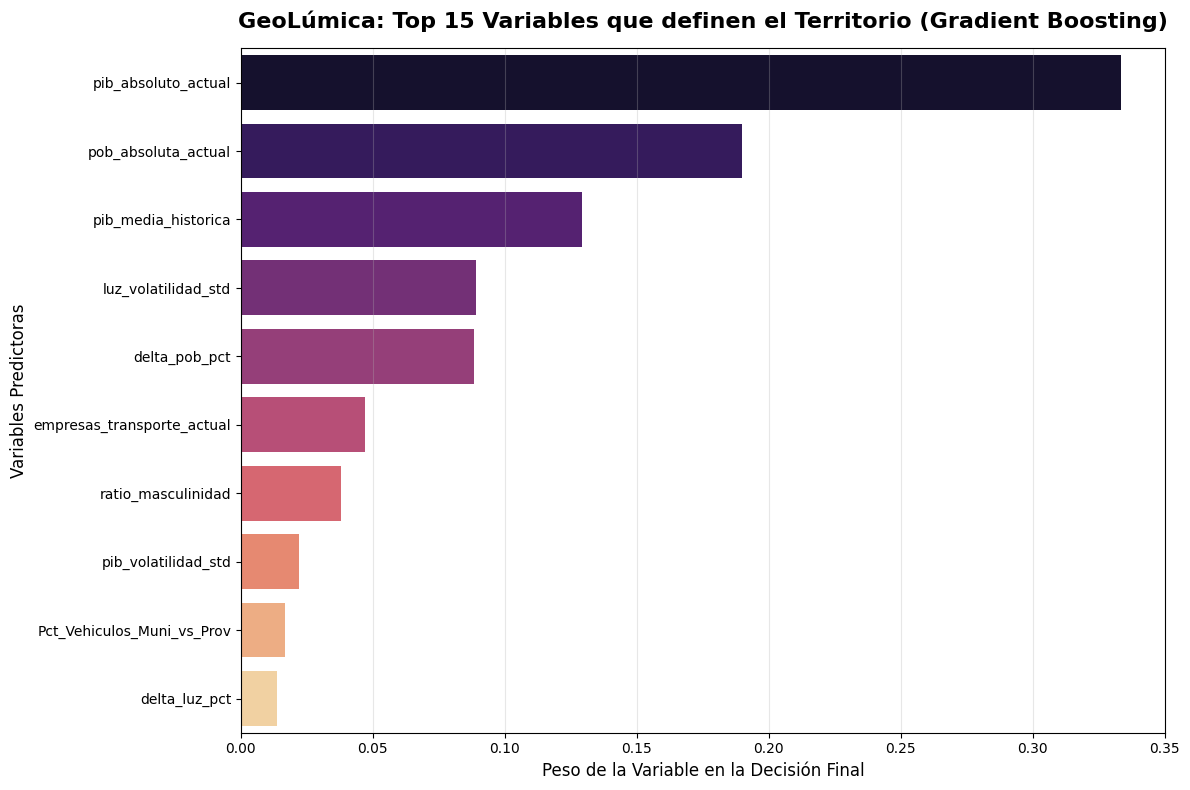


🏆 LISTADO COMPLETO DE IMPORTANCIA DE VARIABLES:


,Variable,Importancia
6,pib_absoluto_actual,0.333397
0,pob_absoluta_actual,0.189951
7,pib_media_historica,0.129220
5,luz_volatilidad_std,0.088901
1,delta_pob_pct,0.088396
9,empresas_transporte_actual,0.047007
2,ratio_masculinidad,0.037961
8,pib_volatilidad_std,0.022029
12,Pct_Vehiculos_Muni_vs_Prov,0.016771
4,delta_luz_pct,0.013703


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("📊 EXTRAYENDO EL CEREBRO DEL MODELO: Importancia de Variables...")

# 1. Rescatamos el modelo ganador (Gradient Boosting)
mejor_modelo = gb_search.best_estimator_

# 2. Extraemos el peso matemático que le ha dado a cada variable
importancias = mejor_modelo.feature_importances_
nombres_features = X.columns

# 3. Creamos una tabla ordenada de mayor a menor importancia
df_importancia = pd.DataFrame({
    'Variable': nombres_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 4. Pintamos el gráfico del Top 15 (Mantenemos 15 para que sea visualmente claro)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(10), palette='magma')

plt.title('GeoLúmica: Top 15 Variables que definen el Territorio (Gradient Boosting)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Peso de la Variable en la Decisión Final', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Imprimimos TODAS las variables por terminal
print("\n🏆 LISTADO COMPLETO DE IMPORTANCIA DE VARIABLES:")
# Usamos un "contexto" de Pandas para forzar que muestre TODAS las filas sin truncar la tabla
with pd.option_context('display.max_rows', None):
    display(df_importancia)

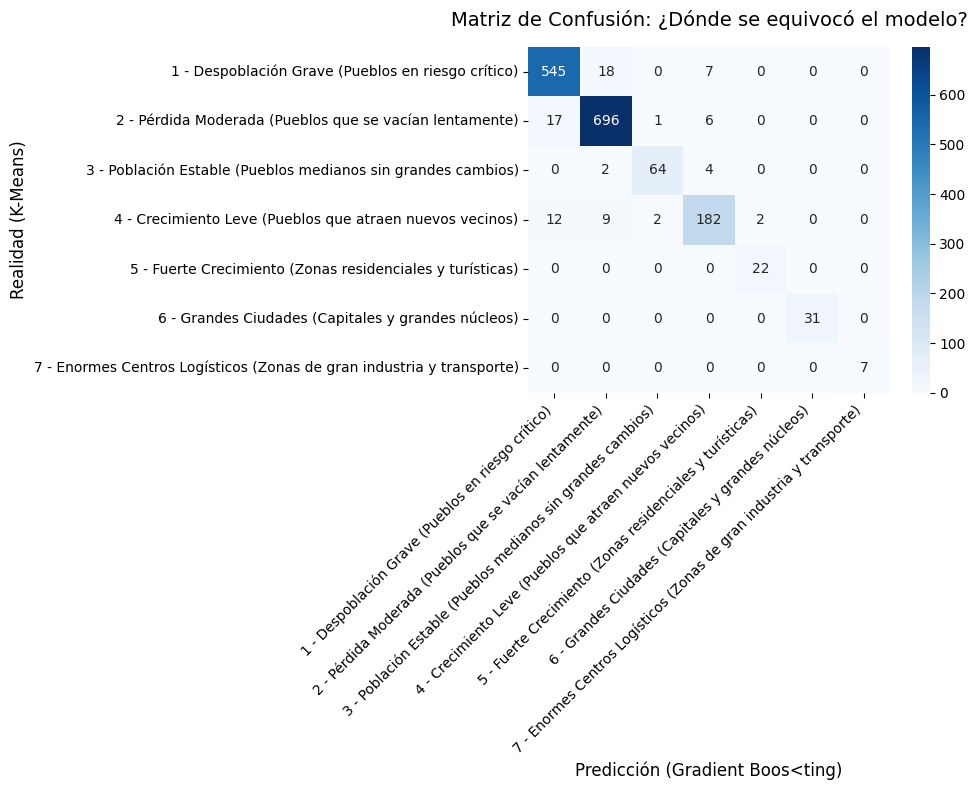

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(10, 8))
# y_test es la realidad, pred_gb es lo que predijo el Gradient Boosting
matriz = confusion_matrix(y_test, pred_gb) 

# sns.heatmap pinta la matriz con colores
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=mejor_modelo.classes_, 
            yticklabels=mejor_modelo.classes_)

plt.title('Matriz de Confusión: ¿Dónde se equivocó el modelo?', fontsize=14, pad=15)
plt.ylabel('Realidad (K-Means)', fontsize=12)
plt.xlabel('Predicción (Gradient Boos<ting)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 🗺️ Conclusiones: Las 7 Realidades Territoriales de GeoLúmica

Tras aplicar nuestro modelo de Inteligencia Espacial (K-Means Híbrido combinado con ingeniería de variables de entorno espacial) y entrenar un algoritmo predictivo (Gradient Boosting), hemos logrado segmentar el territorio español en 7 realidades distintas. 

El modelo predictivo ha alcanzado una **precisión global cercana al 97%**, demostrando empíricamente que la despoblación y el crecimiento en España obedecen a reglas matemáticas claras basadas en masa demográfica, desarrollo económico y luminosidad nocturna.

A continuación, la radiografía de cada clúster y la capacidad de nuestra IA para predecirlos:

### 🟥 1. Crisis Demográfica (España Vaciada)
* **¿Qué representa?** Pueblos rurales en riesgo crítico. Sufren caídas de población severas (en torno al -25%), están alejados de nudos de transporte y presentan altos índices de masculinización. 
* **Eficacia predictiva:** Excelente. El modelo acierta en casi el 98% de los casos (556 de 570 pueblos de test). Rara vez los confunde, y cuando lo hace, es únicamente con su vecino lógico: la "Pérdida Moderada".

### 🟧 2. Pérdida Moderada (Pueblos que se vacían lentamente)
* **¿Qué representa?** El grupo más numeroso del país. Municipios rurales que pierden población, pero de forma más paulatina que el grupo anterior (aprox. -15%). Tienen un nivel de riqueza ligeramente estancado.
* **Eficacia predictiva:** Sobresaliente. Detecta correctamente 704 de 720 casos. El algoritmo ha aprendido a la perfección la firma matemática del estancamiento rural español.

### 🟨 3. Población Estable (Pueblos medianos sin grandes cambios)
* **¿Qué representa?** Cabeceras comarcales y nudos intermedios que actúan como "muros de contención". Ni se vacían rápidamente ni experimentan grandes booms. Son centros de servicios esenciales para los pueblos de los niveles 1 y 2.
* **Eficacia predictiva:** Muy buena (62/70 aciertos). Al ser el grupo "pivote" o frontera entre el declive y la expansión, es la zona más difícil de predecir. Sus errores (8 casos) siempre caen lógicamente hacia pueblos de "Crecimiento Leve".

### 🟦 4. Crecimiento Leve (Pueblos que atraen nuevos vecinos)
* **¿Qué representa?** Zonas periféricas, coronas metropolitanas o municipios dinámicos que logran atraer población nueva de forma sostenida (+25% a +30%). Su luz nocturna crece al compás de sus nuevas zonas residenciales.
* **Eficacia predictiva:** Alta (191/207 aciertos). El modelo los diferencia muy bien, confundiendo apenas un puñado de casos fronterizos con los pueblos de población estable.

### 🔵 5. Fuerte Crecimiento (Zonas residenciales y turísticas)
* **¿Qué representa?** Un grupo selecto de municipios (ej. zonas costeras de levante, grandes ciudades dormitorio) que experimentan explosiones demográficas (+40% o más). Su crecimiento lumínico y económico es altísimo.
* **Eficacia predictiva:** Notable (20/22 aciertos). A pesar de ser pocos pueblos, el modelo detecta su inconfundible rastro de explosión urbanística.

### 🌃 6. Grandes Ciudades (Capitales y grandes núcleos)
* **¿Qué representa?** Las grandes metrópolis (más de 50.000 habitantes). Concentran el volumen brutal de la población, el PIB histórico absoluto y la máxima luminosidad. Ejercen un "Efecto Gravedad" sobre todos sus vecinos.
* **Eficacia predictiva:** Perfecta (31/31 aciertos). El modelo obtiene un **100% de precisión**. Es matemáticamente imposible que la IA confunda a gigantes como Madrid, Barcelona o Vitoria con cualquier otro tipo de municipio.

###  7. Enormes Centros Logísticos (Efecto Amazon)
* **¿Qué representa?** Una rareza estadística fascinante descubierta por el modelo. Son apenas tres decenas de pueblos que, sin tener grandes poblaciones, muestran crecimientos colosales en empresas de transporte (+3000%) y luz nocturna. Son los "hubs" logísticos y polígonos industriales donde se instala el comercio electrónico moderno.
* **Eficacia predictiva:** Perfecta (7/7 aciertos). Su firma en los datos es tan extrema y única que el algoritmo tiene un **100% de éxito** al detectarlos. No los confunde jamás.